In [1]:
import os

In [2]:
%pwd

'c:\\Users\\Lenovo\\Desktop\\mlProject\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\Lenovo\\Desktop\\mlProject'

In [1]:
# necessary imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline
pd.set_option('display.max_columns', 26)

ModuleNotFoundError: No module named 'plotly'

In [84]:
df= pd.read_csv("artifacts/data_ingestion/data.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Data Cleaning & EDA 

In [86]:
# dropping id column
df.drop('id', axis = 1, inplace = True)

In [87]:
# rename column names to make it more user-friendly
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [88]:
df.head(5)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [89]:
# Replace incorrect values in the 'diabetes_mellitus' column
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({
    '\tno': 'no', 
    '\tyes': 'yes', 
    ' yes': 'yes'
})

# Replace incorrect values in the 'coronary_artery_disease' column
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({
    '\tno': 'no'
})

# Replace incorrect values in the 'class' column
df['class'] = df['class'].replace({
    'ckd\t': 'ckd', 
    'notckd': 'not ckd'
})


In [90]:
# Extracting categorical and numerical columns

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [91]:
# looking at unique values in categorical columns

for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

packed_cell_volume has ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54'] values

white_blood_cell_count has ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '4200' '4700' '10900' '8100' '9500' '2200'
 '

In [92]:
import plotly.express as px

# Using a professional color palette for the "class" column
fig = px.scatter(
    df, 
    x="age", 
    y="blood_pressure", 
    color="class",
    color_discrete_sequence=px.colors.qualitative.Set2,  # Professional categorical palette
    title="Scatter Plot: Age vs Blood Pressure by Class",
    labels={
        "age": "Age (Years)",
        "blood_pressure": "Blood Pressure (mmHg)",
        "class": "Health Class"
    },
    template="plotly_white"  # Use a clean template for professional visuals
)

# Customize layout for better appearance
fig.update_layout(
    title_font=dict(size=18, family="Arial", color="darkblue"),
    xaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    yaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    legend_title_font=dict(size=14, family="Arial", color="navy"),
    legend=dict(bordercolor="black", borderwidth=1, bgcolor="rgba(255, 255, 255, 0.9)")
)

# Display the scatter plot
fig.show()


In [52]:
import plotly.express as px

# Using a professional color palette for the "class" column
fig = px.scatter(
    df, 
    x="age", 
    y="sugar", 
    color="class",
    color_discrete_sequence=px.colors.qualitative.Set2,  # Professional categorical palette
    title="Scatter Plot: Age vs Sugar Levels by Class",
    labels={
        "age": "Age (Years)",
        "sugar": "Sugar Level (mg/dL)",
        "class": "Health Class"
    },
    template="plotly_white"  # Use a clean template for professional visuals
)

# Customize layout for better appearance
fig.update_layout(
    title_font=dict(size=18, family="Arial", color="darkblue"),
    xaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    yaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    legend_title_font=dict(size=14, family="Arial", color="navy"),
    legend=dict(bordercolor="black", borderwidth=1, bgcolor="rgba(255, 255, 255, 0.9)")
)

# Display the scatter plot
fig.show()


In [53]:
import plotly.express as px

# Creating a scatter plot with professional design elements
fig = px.scatter(
    df, 
    x="age", 
    y="haemoglobin", 
    color="class",
    marginal_y="violin",  # Add violin plot on the y-axis
    marginal_x="box",     # Add box plot on the x-axis
    color_discrete_sequence=px.colors.qualitative.Set2,  # Professional categorical palette
    title="Scatter Plot: Age vs Haemoglobin Levels by Class with Marginals",
    labels={
        "age": "Age (Years)",
        "haemoglobin": "Haemoglobin (g/dL)",
        "class": "Health Class"
    },
    template="plotly_white"  # Use a clean template for professional visuals
)

# Customize layout for better aesthetics
fig.update_layout(
    title_font=dict(size=18, family="Arial", color="darkblue"),
    xaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    yaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    legend_title_font=dict(size=14, family="Arial", color="navy"),
    legend=dict(bordercolor="black", borderwidth=1, bgcolor="rgba(255, 255, 255, 0.9)"),
    margin=dict(l=40, r=40, t=80, b=40)  # Adjust margins for balanced spacing
)

# Improve gridline visibility and spacing
fig.update_xaxes(showgrid=True, gridcolor="lightgray", zerolinecolor="lightgray")
fig.update_yaxes(showgrid=True, gridcolor="lightgray", zerolinecolor="lightgray")

# Display the enhanced visualization
fig.show()


In [54]:
import plotly.express as px

# Creating a violin plot with professional design elements
fig = px.violin(
    df,
    y="age", 
    x="sugar", 
    color="class", 
    box=True,        # Add box plot inside the violin plot
    points="all",    # Show all data points for better distribution insight
    color_discrete_sequence=px.colors.qualitative.Set2,  # Soft and professional color palette
    title="Violin Plot: Age vs Sugar Level by Class with Box Plot",
    labels={
        "age": "Age (Years)",
        "sugar": "Sugar Level (mg/dL)",
        "class": "Health Class"
    },
    template="plotly_white"  # Use a clean, professional template
)

# Customize layout for better aesthetics
fig.update_layout(
    title_font=dict(size=18, family="Arial", color="darkblue"),
    xaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    yaxis_title_font=dict(size=14, family="Arial", color="darkgreen"),
    legend_title_font=dict(size=14, family="Arial", color="navy"),
    legend=dict(bordercolor="black", borderwidth=1, bgcolor="rgba(255, 255, 255, 0.9)"),
    margin=dict(l=40, r=40, t=80, b=40)  # Adjust margins for balanced spacing
)

# Improve gridline visibility and spacing
fig.update_xaxes(showgrid=True, gridcolor="lightgray", zerolinecolor="lightgray")
fig.update_yaxes(showgrid=True, gridcolor="lightgray", zerolinecolor="lightgray")

# Display the enhanced visualization
fig.show()


In [56]:
import plotly.express as px

# Creating a 3D scatter plot with professional design elements
fig = px.scatter_3d(
    df,
    x='age', 
    y='hypertension', 
    z='sugar', 
    color='class',
    color_discrete_sequence=px.colors.qualitative.Set1,  # A more professional and distinct color palette
    title="3D Scatter Plot: Age vs Hypertension vs Sugar Level by Health Class",
    labels={
        "age": "Age (Years)",
        "hypertension": "Hypertension Level",
        "sugar": "Sugar Level (mg/dL)",
        "class": "Health Class"
    },
)

# Customize layout for better aesthetics
fig.update_layout(
    title_font=dict(size=20, family="Arial", color="darkblue", weight="bold"),
    scene=dict(
        xaxis_title="Age (Years)",
        yaxis_title="Hypertension Level",
        zaxis_title="Sugar Level (mg/dL)",
        xaxis=dict(title_font=dict(size=16, family="Arial", color="darkgreen")),
        yaxis=dict(title_font=dict(size=16, family="Arial", color="darkgreen")),
        zaxis=dict(title_font=dict(size=16, family="Arial", color="darkgreen")),
    ),
    legend_title_font=dict(size=16, family="Arial", color="navy"),
    legend=dict(bordercolor="black", borderwidth=1, bgcolor="rgba(255, 255, 255, 0.9)", font=dict(size=12)),
    margin=dict(l=50, r=50, t=100, b=50),  # Adjust margins for balanced spacing
    height=700  # Adjust height for better 3D visualization
)

# Improve the color and visualization clarity by changing point size and opacity
fig.update_traces(
    marker=dict(size=6, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')),
)

# Display the enhanced 3D scatter plot
fig.show()


In [93]:
df.isna().sum().sort_values(ascending = False)

red_blood_cells            152
red_blood_cell_count       130
white_blood_cell_count     105
potassium                   88
sodium                      87
packed_cell_volume          70
pus_cell                    65
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
bacteria                     4
pus_cell_clumps              4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [94]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [95]:
df[num_cols].isnull().sum()

age                      9
blood_pressure          12
specific_gravity        47
albumin                 46
sugar                   49
blood_glucose_random    44
blood_urea              19
serum_creatinine        17
sodium                  87
potassium               88
haemoglobin             52
dtype: int64

In [96]:
df[cat_cols].isnull().sum()

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [97]:
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample
    
def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [98]:
# filling num_cols null values using random sampling method

for col in num_cols:
    random_value_imputation(col)
df[num_cols].isnull().sum()

age                     0
blood_pressure          0
specific_gravity        0
albumin                 0
sugar                   0
blood_glucose_random    0
blood_urea              0
serum_creatinine        0
sodium                  0
potassium               0
haemoglobin             0
dtype: int64

In [99]:
random_value_imputation('red_blood_cells')
random_value_imputation('pus_cell')

for col in cat_cols:
    impute_mode(col)
df[cat_cols].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [100]:
df.isnull().sum()

age                        0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
haemoglobin                0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin'],
      dtype='object')

### Data Transformation:
* cat_cols: we use LabelEncoder to convert cat values into num labels

* num_cols: we use StanderScaler:
StandardScaler() standardizes the numerical columns by removing the mean and scaling to unit variance. This is useful for many machine learning algorithms, especially when features have different units or scales.
fit_transform() first computes the mean and standard deviation of the numerical columns and then scales them accordingly.

In [73]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [107]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [109]:
scaler = StandardScaler()
for col in num_cols:
    df[col]= scaler.fit_transform(df[num_cols])

In [110]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,0,1,0,0,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,32,72,34,1,1,0,0,0,0,0
1,-2.623124,-2.623124,-2.623124,-2.623124,-2.623124,1,1,0,0,-2.623124,-2.623124,-2.623124,-2.623124,-2.623124,-2.623124,26,56,34,0,0,0,0,0,0,0
2,0.605336,0.605336,0.605336,0.605336,0.605336,1,1,0,0,0.605336,0.605336,0.605336,0.605336,0.605336,0.605336,19,70,34,0,1,0,1,0,1,0
3,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,1,0,1,0,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,-0.216454,20,62,19,1,0,0,1,1,1,0
4,-0.040356,-0.040356,-0.040356,-0.040356,-0.040356,1,1,0,0,-0.040356,-0.040356,-0.040356,-0.040356,-0.040356,-0.040356,23,68,27,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.194441,0.194441,0.194441,0.194441,0.194441,1,1,0,0,0.194441,0.194441,0.194441,0.194441,0.194441,0.194441,35,62,30,0,0,0,0,0,0,1
396,-0.568649,-0.568649,-0.568649,-0.568649,-0.568649,1,1,0,0,-0.568649,-0.568649,-0.568649,-0.568649,-0.568649,-0.568649,42,72,44,0,0,0,0,0,0,1
397,-2.329627,-2.329627,-2.329627,-2.329627,-2.329627,1,1,0,0,-2.329627,-2.329627,-2.329627,-2.329627,-2.329627,-2.329627,37,61,36,0,0,0,0,0,0,1
398,-2.036131,-2.036131,-2.036131,-2.036131,-2.036131,1,1,0,0,-2.036131,-2.036131,-2.036131,-2.036131,-2.036131,-2.036131,39,67,41,0,0,0,0,0,0,1


Remarque : ckd => 0  / not ckd => 1

# Modeling 

### Why Use Train and Test Splits?
- The primary reason for using separate training and testing datasets is to ensure that the model generalizes well to unseen data. This separation helps to evaluate how well the model can make predictions on new, unseen data, which is crucial for understanding its real-world performance.

In [127]:
train_data= pd.read_csv("artifacts/data_training/train.csv")
test_data= pd.read_csv("artifacts/data_training/train.csv")

### First try

In [120]:
# Separate features and target variable
X_train = train_data.drop(columns=["class"])
y_train = train_data["class"]

X_test = test_data.drop(columns=["class"])
y_test = test_data["class"]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
#import lightgbm as lgb # type: ignore
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, f1_score

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)  # Suppress CatBoost output
}

# Train the models
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
    f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted F1 score
    
    results[model_name] = [accuracy, rmse, f1]

# Convert results into a DataFrame for easy comparison
results_df = pd.DataFrame(results, index=["Accuracy", "RMSE", "F1 Score"])


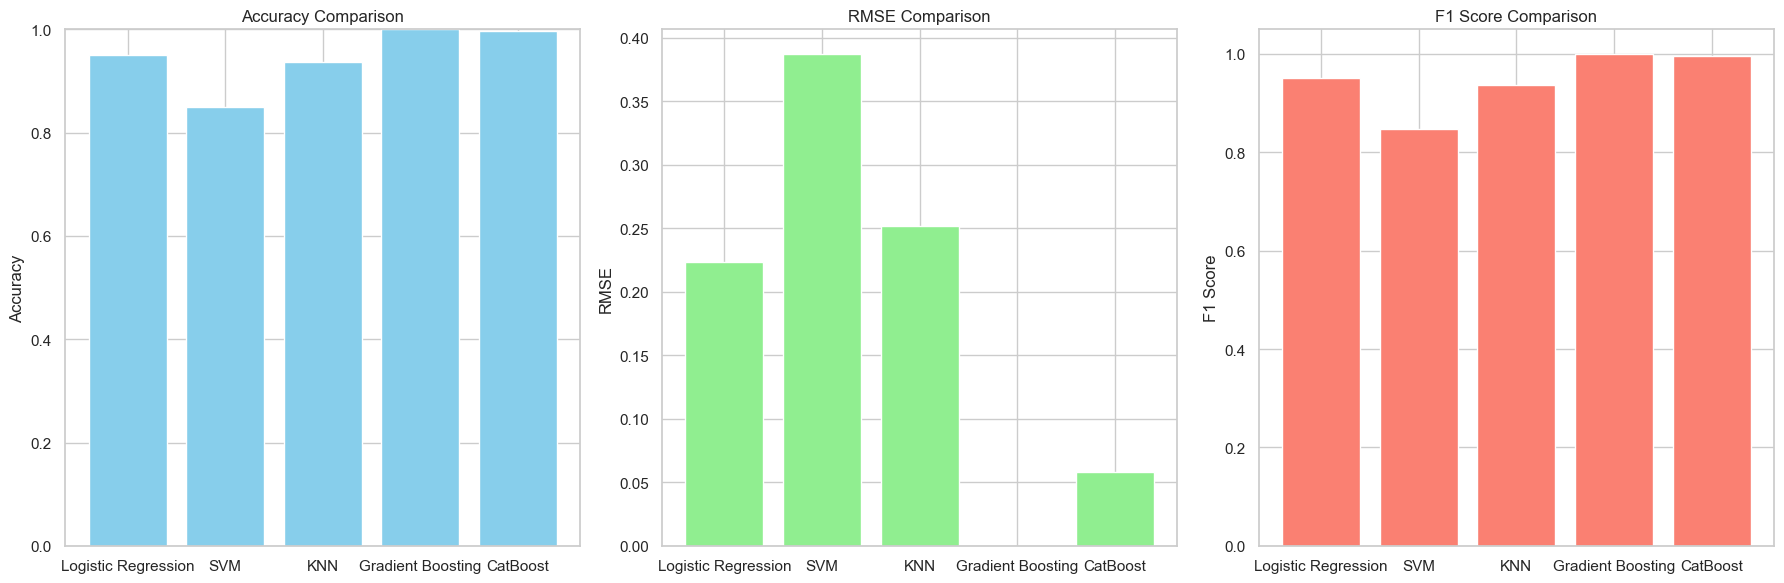

In [126]:
import matplotlib.pyplot as plt

# Create subplots for visualizing each metric
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plot accuracy
ax[0].bar(results_df.columns, results_df.loc["Accuracy"], color='skyblue')
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

# Plot RMSE
ax[1].bar(results_df.columns, results_df.loc["RMSE"], color='lightgreen')
ax[1].set_title('RMSE Comparison')
ax[1].set_ylabel('RMSE')

# Plot F1 Score
ax[2].bar(results_df.columns, results_df.loc["F1 Score"], color='salmon')
ax[2].set_title('F1 Score Comparison')
ax[2].set_ylabel('F1 Score')

# Show the plot
plt.tight_layout()
plt.show()


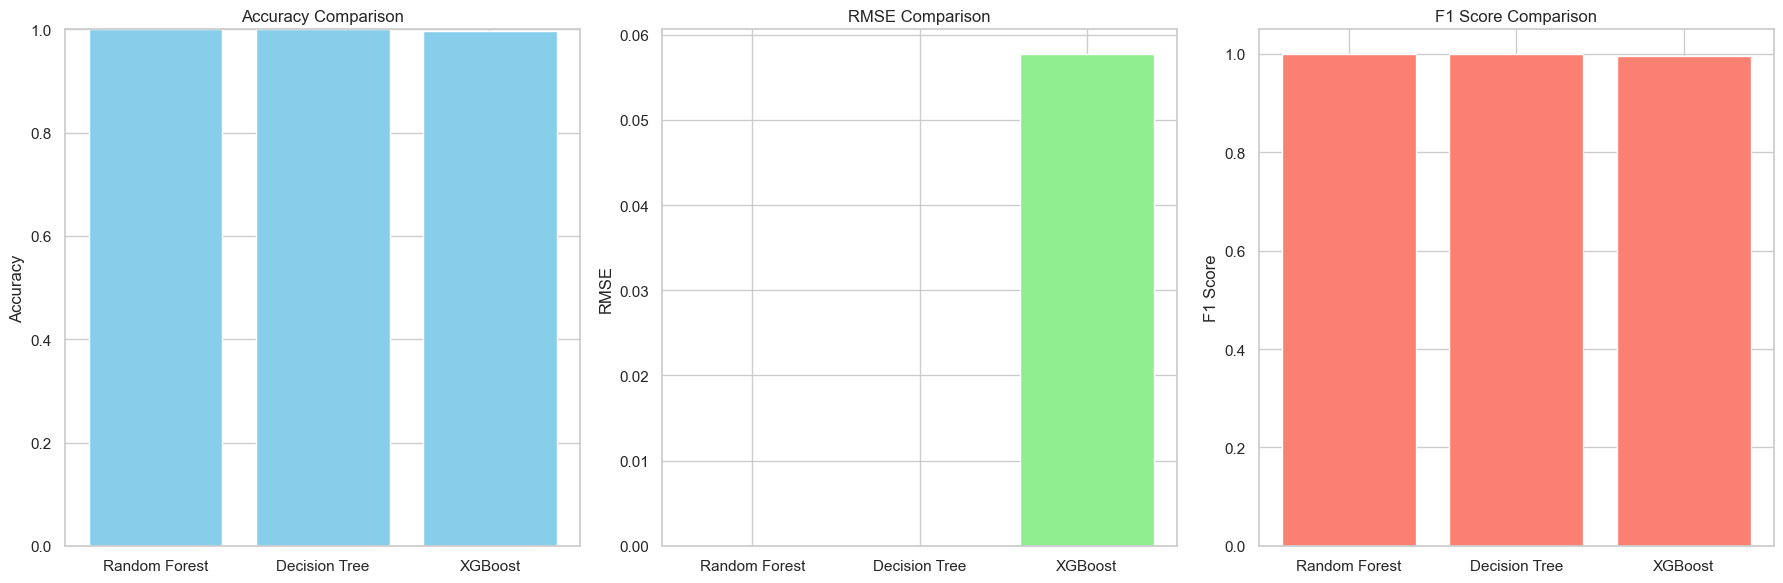

In [118]:
import matplotlib.pyplot as plt

# Create subplots for visualizing each metric
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plot accuracy
ax[0].bar(results_df.columns, results_df.loc["Accuracy"], color='skyblue')
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

# Plot RMSE
ax[1].bar(results_df.columns, results_df.loc["RMSE"], color='lightgreen')
ax[1].set_title('RMSE Comparison')
ax[1].set_ylabel('RMSE')

# Plot F1 Score
ax[2].bar(results_df.columns, results_df.loc["F1 Score"], color='salmon')
ax[2].set_title('F1 Score Comparison')
ax[2].set_ylabel('F1 Score')

# Show the plot
plt.tight_layout()
plt.show()


### Second Try with hyperparameters because the is overfitting 

In [131]:

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

train_data= pd.read_csv("artifacts/data_training/train.csv")
test_data= pd.read_csv("artifacts/data_training/train.csv")

In [132]:

# Separate features and target
X_train_full = train_data.drop('class', axis=1)
y_train_full = train_data['class']
X_test = test_data.drop('class', axis=1)
y_test = test_data['class']

In [133]:
# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

Training Logistic Regression...
Logistic Regression Results:
Accuracy: 0.9667
F1 Score: 0.9565
RMSE: 0.1826

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.92      1.00      0.96        22

    accuracy                           0.97        60
   macro avg       0.96      0.97      0.96        60
weighted avg       0.97      0.97      0.97        60



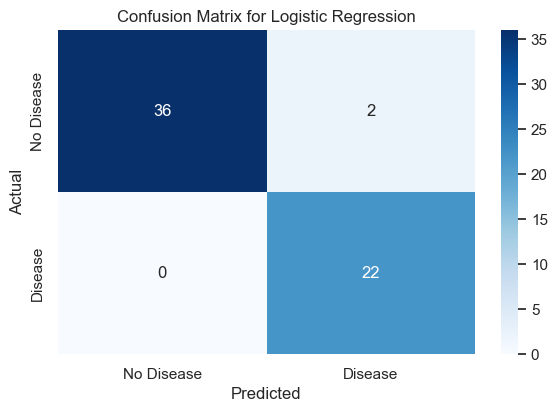

Training Random Forest...
Random Forest Results:
Accuracy: 0.9667
F1 Score: 0.9565
RMSE: 0.1826

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.92      1.00      0.96        22

    accuracy                           0.97        60
   macro avg       0.96      0.97      0.96        60
weighted avg       0.97      0.97      0.97        60



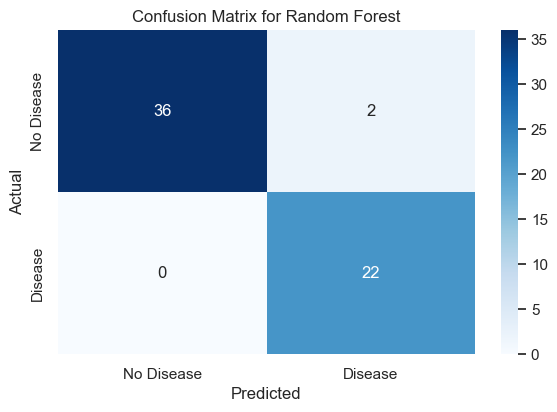

Training Support Vector Machine...
Support Vector Machine Results:
Accuracy: 0.8000
F1 Score: 0.7391
RMSE: 0.4472

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        38
           1       0.71      0.77      0.74        22

    accuracy                           0.80        60
   macro avg       0.78      0.79      0.79        60
weighted avg       0.81      0.80      0.80        60



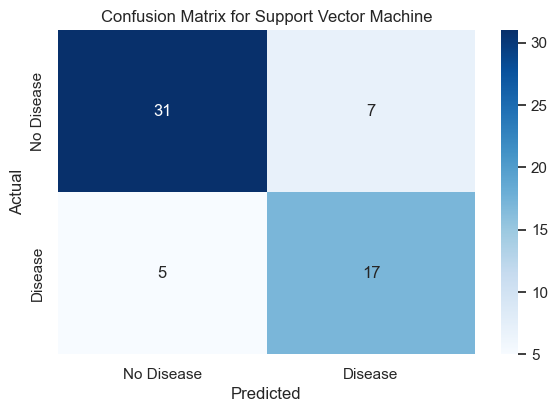

Training XGBoost...
XGBoost Results:
Accuracy: 0.9333
F1 Score: 0.9130
RMSE: 0.2582

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95        38
           1       0.88      0.95      0.91        22

    accuracy                           0.93        60
   macro avg       0.92      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



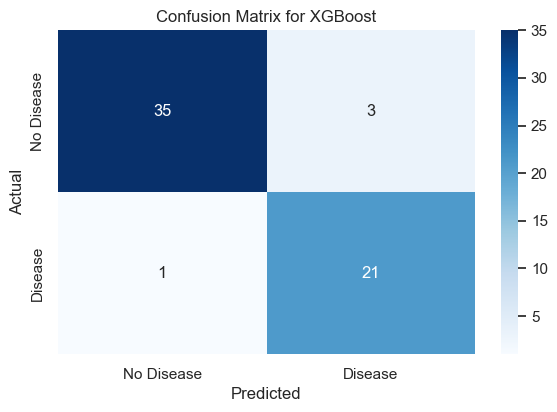

In [136]:

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on validation data
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='binary')
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    print(f"{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Store results
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_score": f1,
        "rmse": rmse
    }
    

Comparison of Models:
                                                                    model  \
Logistic Regression     LogisticRegression(max_iter=1000, random_state...   
Random Forest           (DecisionTreeClassifier(max_features='sqrt', r...   
XGBoost                 XGBClassifier(base_score=None, booster=None, c...   
Support Vector Machine             SVC(probability=True, random_state=42)   

                        accuracy  f1_score      rmse  
Logistic Regression     0.966667  0.956522  0.182574  
Random Forest           0.966667  0.956522  0.182574  
XGBoost                 0.933333  0.913043  0.258199  
Support Vector Machine       0.8   0.73913  0.447214  

Evaluating Logistic Regression on the test dataset...
Test Accuracy: 0.9500
Test F1 Score: 0.9345
Test RMSE: 0.2236


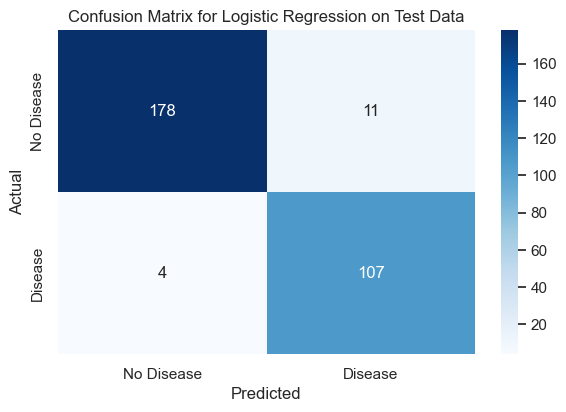

In [137]:

# Compare and select the best model
print("Comparison of Models:")
results_df = pd.DataFrame(results).T.sort_values(by='accuracy', ascending=False)
print(results_df)

# Test the best model on the test dataset
best_model_name = results_df.index[0]
best_model = results[best_model_name]["model"]
print(f"\nEvaluating {best_model_name} on the test dataset...")
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Confusion Matrix for the test set
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix for {best_model_name} on Test Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# To sum up


### Comparison of Models:
#### Logistic Regression:
- Validation Accuracy: 96.67%
- F1 Score: 95.65%
- RMSE: 0.1826
#### Random Forest:
- Validation Accuracy: 96.67%
- F1 Score: 95.65%
- RMSE: 0.1826
#### XGBoost:
- Validation Accuracy: 93.33%
- F1 Score: 91.30%
- RMSE: 0.2582
#### Support Vector Machine (SVM): 
- Validation Accuracy: 80.00%
- F1 Score: 73.91%
- RMSE: 0.4472

## Why Logistic Regression is the Best Choice?
* Performance on Validation Data: Logistic Regression and Random Forest both achieved the highest validation accuracy (96.67%) and F1 score (95.65%). However:
Logistic Regression is simpler and computationally efficient compared to Random Forest.
Random Forest, being an ensemble method, is more prone to overfitting when compared to Logistic Regression, especially for datasets that may not have many complex interactions among features.
* Performance on Test Data:
- Logistic Regression achieved 95.00% test accuracy, 93.45% F1 score, and a lower RMSE (0.2236) than other models. This consistency between validation and test performance suggests it generalizes well.
Interpretability:
- Logistic Regression provides interpretable results by assigning weights to features, making it easier to explain why the model made a specific prediction. For a critical healthcare application like kidney disease prediction, interpretability is a significant advantage.
* Simplicity and Scalability:
Logistic Regression is faster and less resource-intensive to train and deploy. This simplicity is particularly advantageous if the model will be frequently retrained with updated data or deployed in a low-resource environment.

## Why Not the Other Models?
- Random Forest:
Although it performed as well as Logistic Regression on validation data, it adds complexity without noticeable improvement. Additionally, ensemble methods can be computationally expensive when applied to large datasets or used in real-time applications.
- XGBoost:
XGBoost had slightly lower validation and test scores (93.33% accuracy, 91.30% F1 score). While it excels in handling complex feature interactions, the marginal improvement over simpler models doesn't justify its computational cost for this problem.
- Support Vector Machine:
SVM significantly underperformed with an accuracy of 80.00% and an F1 score of 73.91%. This indicates it struggles to capture patterns in the dataset, potentially due to its sensitivity to feature scaling or the choice of kernel.

# Conclusion:
Logistic Regression is the optimal choice for this problem due to its:
High accuracy and F1 score on both validation and test datasets.
Simplicity and computational efficiency.
Robust generalization, as indicated by its consistent performance across validation and test sets.
Interpretability, which is crucial for healthcare-related applications.

